In [3]:
import pandas as pd

In [4]:
data=pd.read_csv("TATACOFFEE13_21.csv")
data

,Date,Open,High,Low,Close
0,2013-01-01,1410.60,1427.90,1408.30,1415.10
1,2013-01-02,1421.00,1626.60,1416.15,1607.40
2,2013-01-03,1632.55,1673.90,1613.05,1626.20
3,2013-01-04,1627.75,1627.75,1574.60,1579.05
4,2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...,...
2220,2021-12-22,202.90,207.80,201.35,205.00
2221,2021-12-23,206.00,206.85,202.05,202.95
2222,2021-12-24,203.90,203.90,199.35,201.00
2223,2021-12-27,200.00,222.00,196.00,218.35


In [5]:
column = "Close"

from sklearn.preprocessing import MinMaxScaler

Ms = MinMaxScaler()

data1 = Ms.fit_transform(data[[column]])

print("Len:", data1.shape)

Len: (2225, 1)


In [6]:
training_size = round(len(data1) * 0.80)

print(training_size)

X_train = data1[:training_size]
X_test = data1[training_size:]

print("X_train length:", X_train.shape)
print("X_test length:", X_test.shape)

y_train = data1[:training_size]
y_test = data1[training_size:]

print("y_train length:", y_train.shape)
print("y_test length:", y_test.shape)

1780
X_train length: (1780, 1)
X_test length: (445, 1)
y_train length: (1780, 1)
y_test length: (445, 1)


In [8]:
from sklearn.metrics import mean_squared_error

trends = ['n', 'c', 'ct', 'ct']
lags = [1, 2, 3, 4]

from statsmodels.tsa.ar_model import AutoReg

for i in lags:

    for td in trends:

        model = AutoReg(
            X_train,
            lags=i,
            trend=td
        )

        model_fit = model.fit()

        # Make prediction
        y_pred = model_fit.predict(
            len(X_train),
            len(data1) - 1
        )

        # Calculate MSE
        mse = mean_squared_error(
            y_test,
            y_pred
        )

        # Calculate RMSE
        rmse_value = mse ** 0.5

        print("Lag={0}, Trend={1}".format(i, td))
        print("MSE:", mse)
        print("RMSE:", rmse_value)
        print("***************")

Lag=1, Trend=n
MSE: 0.0034644227662105017
RMSE: 0.058859347313833695
***************
Lag=1, Trend=c
MSE: 0.0018805449368485523
RMSE: 0.043365250337667284
***************
Lag=1, Trend=ct
MSE: 0.02332857402067153
RMSE: 0.152736943863204
***************
Lag=1, Trend=ct
MSE: 0.02332857402067153
RMSE: 0.152736943863204
***************
Lag=2, Trend=n
MSE: 0.003536630045932716
RMSE: 0.059469572437782975
***************
Lag=2, Trend=c
MSE: 0.001216024556494223
RMSE: 0.034871543649431735
***************
Lag=2, Trend=ct
MSE: 0.022943396798261496
RMSE: 0.15147077869431283
***************
Lag=2, Trend=ct
MSE: 0.022943396798261496
RMSE: 0.15147077869431283
***************
Lag=3, Trend=n
MSE: 0.003533464899580025
RMSE: 0.05944295500376832
***************
Lag=3, Trend=c
MSE: 0.0012987369051811212
RMSE: 0.03603799252429471
***************
Lag=3, Trend=ct
MSE: 0.021678190398649943
RMSE: 0.14723515340654875
***************
Lag=3, Trend=ct
MSE: 0.021678190398649943
RMSE: 0.14723515340654875
*************

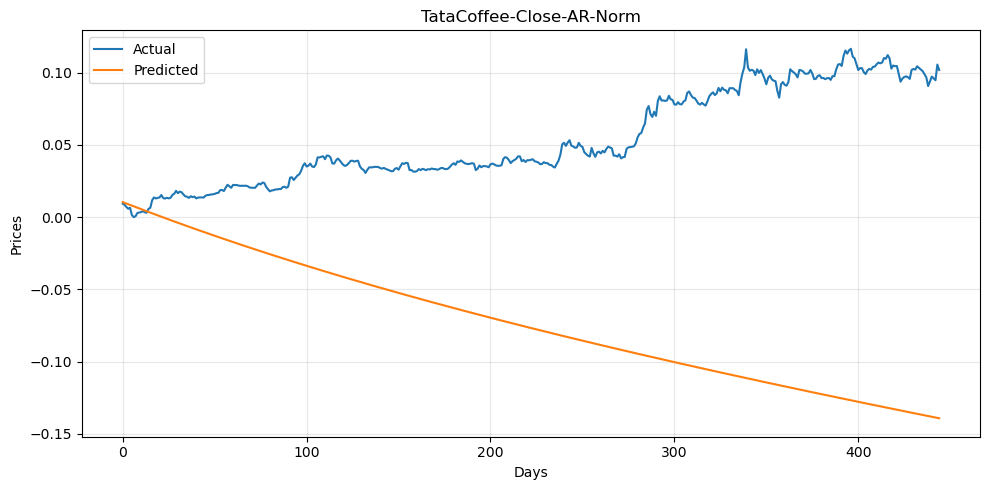

In [9]:
from stockFunctions import graph

graph(
    y_test,
    y_pred,
    "Actual",
    "Predicted",
    "TataCoffee-Close-AR-Norm",
    "Days",
    "Prices"
)

In [16]:
forecast = model_fit.predict(
    len(data),
    len(data) + 3
)

forecast

array([-0.13951498, -0.13976943, -0.14002371, -0.14027783])

In [17]:
from stockFunctions import conversionSingle

TestNormalStock = conversionSingle(
    forecast,
    "Closeforecast"
)

TestNormalStock

,Closeforecast
0,-0.139515
1,-0.139769
2,-0.140024
3,-0.140278


In [13]:
from statsmodels.tsa.ar_model import AutoReg
from stockFunctions import rmsemape

trends = ['n', 'c', 'ct', 'ct']
lags = [1, 2, 3, 4]

for i in lags:

    for td in trends:

        model = AutoReg(
            X_train,
            lags=i,
            trend=td
        )

        model_fit = model.fit()

        # Make prediction
        y_pred = model_fit.predict(
            len(X_train),
            len(data) - 1
        )

        rmsemape(y_test, y_pred)

        print("Lag={0}, Trend={1}".format(i, td))
        print("***************")

RMSE-Testset: 0.058859347313833695
MAPE-Testset: 108221610722.61476
Lag=1, Trend=n
***************
RMSE-Testset: 0.043365250337667284
MAPE-Testset: 114804919729.44038
Lag=1, Trend=c
***************
RMSE-Testset: 0.152736943863204
MAPE-Testset: 74699776526.6675
Lag=1, Trend=ct
***************
RMSE-Testset: 0.152736943863204
MAPE-Testset: 74699776526.6675
Lag=1, Trend=ct
***************
RMSE-Testset: 0.059469572437782975
MAPE-Testset: 107811149748.47629
Lag=2, Trend=n
***************
RMSE-Testset: 0.034871543649431735
MAPE-Testset: 119368707397.77797
Lag=2, Trend=c
***************
RMSE-Testset: 0.15147077869431283
MAPE-Testset: 72770748055.75784
Lag=2, Trend=ct
***************
RMSE-Testset: 0.15147077869431283
MAPE-Testset: 72770748055.75784
Lag=2, Trend=ct
***************
RMSE-Testset: 0.05944295500376832
MAPE-Testset: 108331645493.58661
Lag=3, Trend=n
***************
RMSE-Testset: 0.03603799252429471
MAPE-Testset: 119319866515.31133
Lag=3, Trend=c
***************
RMSE-Testset: 0.147235

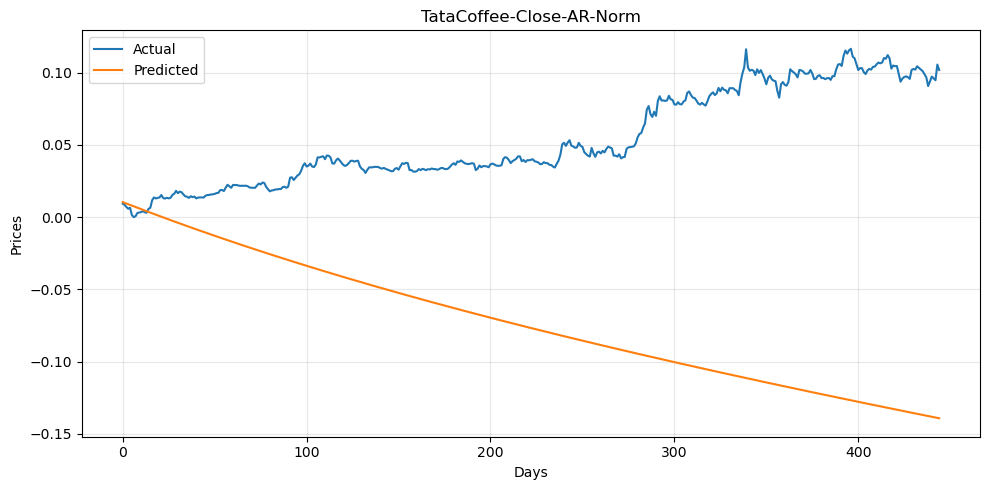

In [14]:
from stockFunctions import graph

graph(
    y_test,
    y_pred,
    "Actual",
    "Predicted",
    "TataCoffee-Close-AR-Norm",
    "Days",
    "Prices"
)

In [20]:
len(data)

2225

In [21]:
y_test

array([[0.00931949],
       [0.00856893],
       [0.0070678 ],
       [0.00581686],
       [0.00650488],
       [0.00140731],
       [0.        ],
       [0.00068802],
       [0.0029397 ],
       [0.00325244],
       [0.00350263],
       [0.00422192],
       [0.00337753],
       [0.0030648 ],
       [0.00569177],
       [0.00650488],
       [0.01169627],
       [0.0136665 ],
       [0.01294721],
       [0.01335377],
       [0.01363523],
       [0.01532399],
       [0.01322867],
       [0.01288466],
       [0.01341631],
       [0.01300976],
       [0.01338504],
       [0.01535527],
       [0.01616838],
       [0.01820115],
       [0.0166062 ],
       [0.01770078],
       [0.01723167],
       [0.01573055],
       [0.01444834],
       [0.01416688],
       [0.01335377],
       [0.01447961],
       [0.01382287],
       [0.0142607 ],
       [0.01297848],
       [0.01360395],
       [0.01363523],
       [0.01369777],
       [0.01354141],
       [0.01485489],
       [0.01529272],
       [0.015

In [22]:
i = 1
td = 'ct'

model = AutoReg(X_train, lags=i, trend=td)

model_fit = model.fit()

# make prediction
y_pred = model_fit.predict(
    len(X_train),
    len(data1) - 1
)

from sklearn.metrics import mean_squared_error

rmse = mean_squared_error(y_test, y_pred)

from stockFunctions import rmsemape

print("Lag={0}, Trend={1}".format(i, td))

rmsemape(y_test, y_pred)

print("***************")

Lag=1, Trend=ct
RMSE-Testset: 0.152736943863204
MAPE-Testset: 74699776526.6675
***************


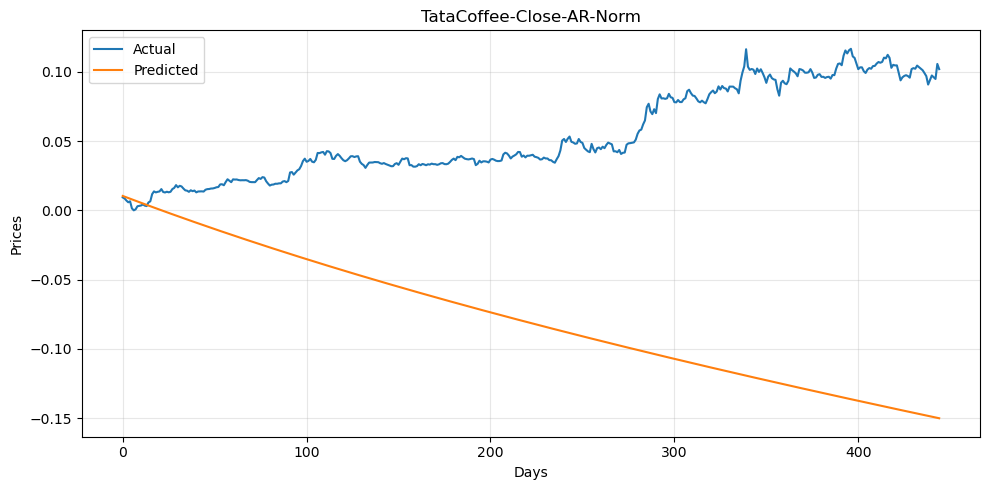

In [23]:
from stockFunctions import graph

graph(
    y_test,
    y_pred,
    "Actual",
    "Predicted",
    "TataCoffee-Close-AR-Norm",
    "Days",
    "Prices"
)